# NBI Storage Format Analysis

This notebook summarizes storage sizes and simple metrics for different file formats generated from the NBI 1992–2015 CSV corpus.

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RAW_ROOT = Path('../nbi_data_cleaner/data/raw')
CSV_GZIP_ROOT = Path('data/storage/csv_gzip')
PARQUET_SNAPPY_ROOT = Path('data/storage/parquet_snappy')
PARQUET_ZSTD_ROOT = Path('data/storage/parquet_zstd')
ORC_SNAPPY_ROOT = Path('data/storage/orc_snappy')

def dir_size_mb(root: Path) -> float:
    return sum(p.stat().st_size for p in root.rglob('*') if p.is_file()) / 1024 / 1024

sizes = {
    'CSV (raw)': dir_size_mb(RAW_ROOT),
    'ORC (Snappy)': dir_size_mb(ORC_SNAPPY_ROOT),
    'CSV + gzip': dir_size_mb(CSV_GZIP_ROOT),
    'Parquet (Snappy)': dir_size_mb(PARQUET_SNAPPY_ROOT),
    'Parquet (ZSTD)': dir_size_mb(PARQUET_ZSTD_ROOT),
    
}

sizes_df = pd.DataFrame([{'format': k, 'size_mb': v} for k, v in sizes.items()])
sizes_df['size_gb'] = sizes_df['size_mb'] / 1024
sizes_df['compression_ratio_vs_csv'] = sizes_df.loc[sizes_df['format'] == 'CSV (raw)', 'size_gb'].iloc[0] / sizes_df['size_gb']
sizes_df

,format,size_mb,size_gb,compression_ratio_vs_csv
0,CSV (raw),9792.828612,9.563309,1.000000
1,ORC (Snappy),2297.540703,2.243692,4.262309
2,CSV + gzip,1591.414515,1.554116,6.153537
3,Parquet (Snappy),1406.182815,1.373225,6.964122
4,Parquet (ZSTD),1406.182815,1.373225,6.964122


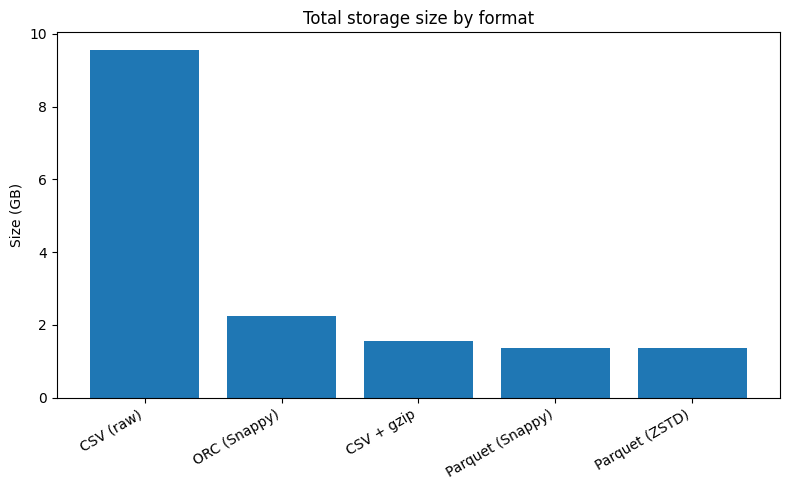

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(sizes_df['format'], sizes_df['size_gb'])
plt.ylabel('Size (GB)')
plt.xticks(rotation=30, ha='right')
plt.title('Total storage size by format')
plt.tight_layout()
plt.show()


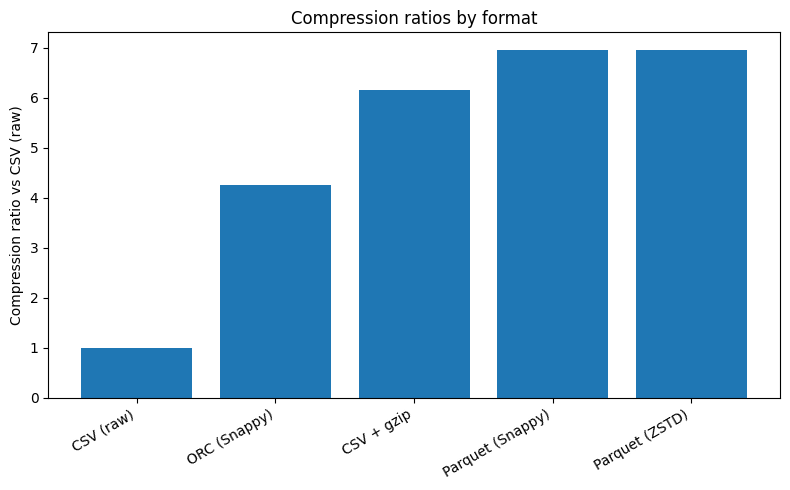

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(sizes_df['format'], sizes_df['compression_ratio_vs_csv'])
plt.ylabel('Compression ratio vs CSV (raw)')
plt.xticks(rotation=30, ha='right')
plt.title('Compression ratios by format')
plt.tight_layout()
plt.show()


In [8]:
# plt.figure(figsize=(8, 5))

# # Line + markers instead of bars
# plt.plot(
#     sizes_df['format'],
#     sizes_df['size_gb'],
#     marker='o',
#     linestyle='-'
# )

# plt.ylabel('Size (GB)')
# plt.xticks(rotation=30, ha='right')
# plt.title('Total storage size by format')
# plt.tight_layout()
# plt.show()